# Sensor CSV to Step Speed CSV

This notebook reads a sensor CSV, detects steps from the accelerometer signal, calculates the speed between each detected step, and saves the combined result to a new CSV file.

In [26]:
from pathlib import Path
import csv
import datetime as dt
import math
import statistics

INPUT_CSV = Path("../data/sensor_data_20260516_225339.csv")
OUTPUT_CSV = Path("../results/sensor_step_speed.csv")

# Detection parameter tweaks for higher sensitivity
SMOOTH_WINDOW = 3
MIN_INTERVAL_MS = 200
GRAVITY = 9.81
MOTION_THRESHOLD_FLOOR = 0.20
PROMINENCE_MIN = 0.12

In [27]:
def moving_average(values: list[float], window: int) -> list[float]:
    if window <= 1 or not values:
        return values[:]

    out: list[float] = []
    running = 0.0
    queue: list[float] = []

    for value in values:
        queue.append(value)
        running += value
        if len(queue) > window:
            running -= queue.pop(0)
        out.append(running / len(queue))

    return out


def robust_threshold(values: list[float], floor: float = MOTION_THRESHOLD_FLOOR) -> float:
    if not values:
        return floor

    median = statistics.median(values)
    deviations = [abs(value - median) for value in values]
    mad = statistics.median(deviations)
    return median + max(floor, 2.5 * mad)


def load_accelerometer_samples(path: Path) -> tuple[list[int], list[float]]:
    timestamps: list[int] = []
    magnitudes: list[float] = []

    with path.open("r", newline="") as file:
        reader = csv.DictReader(file)
        for row in reader:
            if row.get("sensor") != "Accelerometer":
                continue
            timestamp_ms = int(row["timestamp"])
            x = float(row["x"])
            y = float(row["y"])
            z = float(row["z"])
            magnitude = math.sqrt(x * x + y * y + z * z)
            timestamps.append(timestamp_ms)
            magnitudes.append(magnitude)

    return timestamps, magnitudes


def detect_step_timestamps(
    timestamps_ms: list[int],
    magnitudes: list[float],
    gravity: float = GRAVITY,
    smooth_window: int = SMOOTH_WINDOW,
    min_interval_ms: int = MIN_INTERVAL_MS,
) -> list[int]:
    if len(timestamps_ms) < 3:
        return []

    dynamic = [abs(magnitude - gravity) for magnitude in magnitudes]
    signal = moving_average(dynamic, smooth_window)
    threshold = robust_threshold(signal)

    step_indices: list[int] = []
    last_ts = -10**18

    for i in range(1, len(signal) - 1):
        center = signal[i]
        if center < threshold:
            continue
        if not (center > signal[i - 1] and center >= signal[i + 1]):
            continue

        left = min(signal[max(0, i - 3):i])
        right = min(signal[i + 1:min(len(signal), i + 4)])
        prominence = center - max(left, right)
        if prominence < PROMINENCE_MIN:
            continue

        timestamp_ms = timestamps_ms[i]
        if timestamp_ms - last_ts < min_interval_ms:
            continue

        step_indices.append(i)
        last_ts = timestamp_ms

    return [timestamps_ms[index] for index in step_indices]


def ms_to_iso8601(timestamp_ms: int) -> str:
    return dt.datetime.fromtimestamp(timestamp_ms / 1000.0, tz=dt.timezone.utc).isoformat()

In [28]:
from bisect import bisect_left

timestamps_ms, magnitudes = load_accelerometer_samples(INPUT_CSV)
step_timestamps_ms = detect_step_timestamps(timestamps_ms, magnitudes)

rows: list[dict[str, object]] = []
previous_timestamp_ms: int | None = None


def find_nearest_magnitude(ts: int) -> float:
    pos = bisect_left(timestamps_ms, ts)
    if pos == 0:
        return magnitudes[0]
    if pos >= len(timestamps_ms):
        return magnitudes[-1]
    before_ts = timestamps_ms[pos - 1]
    after_ts = timestamps_ms[pos]
    if abs(ts - before_ts) <= abs(after_ts - ts):
        return magnitudes[pos - 1]
    return magnitudes[pos]

for step_number, timestamp_ms in enumerate(step_timestamps_ms, start=1):
    if previous_timestamp_ms is None:
        delta_ms = None
        speed_spm = None
    else:
        delta_ms = timestamp_ms - previous_timestamp_ms
        speed_spm = 60000.0 / delta_ms if delta_ms > 0 else None

    accel_mag = find_nearest_magnitude(timestamp_ms)

    rows.append(
        {
            "step_number": step_number,
            "timestamp_ms": timestamp_ms,
            "timestamp_utc": ms_to_iso8601(timestamp_ms),
            "delta_ms": delta_ms,
            "speed_spm": speed_spm,
            "accel_magnitude": accel_mag,
        }
    )

    previous_timestamp_ms = timestamp_ms

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
with OUTPUT_CSV.open("w", newline="") as file:
    writer = csv.DictWriter(
        file,
        fieldnames=["step_number", "timestamp_ms", "timestamp_utc", "delta_ms", "speed_spm", "accel_magnitude"],
    )
    writer.writeheader()
    writer.writerows(rows)

print(f"Loaded accelerometer samples: {len(timestamps_ms)}")
print(f"Detected steps: {len(step_timestamps_ms)}")
print(f"Saved combined CSV to: {OUTPUT_CSV}")

rows[:5]

Loaded accelerometer samples: 12250
Detected steps: 267
Saved combined CSV to: ../results/sensor_step_speed.csv


[{'step_number': 1,
  'timestamp_ms': 1778964584981,
  'timestamp_utc': '2026-05-16T20:49:44.981000+00:00',
  'delta_ms': None,
  'speed_spm': None,
  'accel_magnitude': 37.59064427895592},
 {'step_number': 2,
  'timestamp_ms': 1778964586170,
  'timestamp_utc': '2026-05-16T20:49:46.170000+00:00',
  'delta_ms': 1189,
  'speed_spm': 50.462573591253154,
  'accel_magnitude': 33.36434965718506},
 {'step_number': 3,
  'timestamp_ms': 1778964587607,
  'timestamp_utc': '2026-05-16T20:49:47.607000+00:00',
  'delta_ms': 1437,
  'speed_spm': 41.75365344467641,
  'accel_magnitude': 35.15303170802912},
 {'step_number': 4,
  'timestamp_ms': 1778964588908,
  'timestamp_utc': '2026-05-16T20:49:48.908000+00:00',
  'delta_ms': 1301,
  'speed_spm': 46.11837048424289,
  'accel_magnitude': 23.280031681838008},
 {'step_number': 5,
  'timestamp_ms': 1778964590215,
  'timestamp_utc': '2026-05-16T20:49:50.215000+00:00',
  'delta_ms': 1307,
  'speed_spm': 45.90665646518745,
  'accel_magnitude': 24.1227091628035

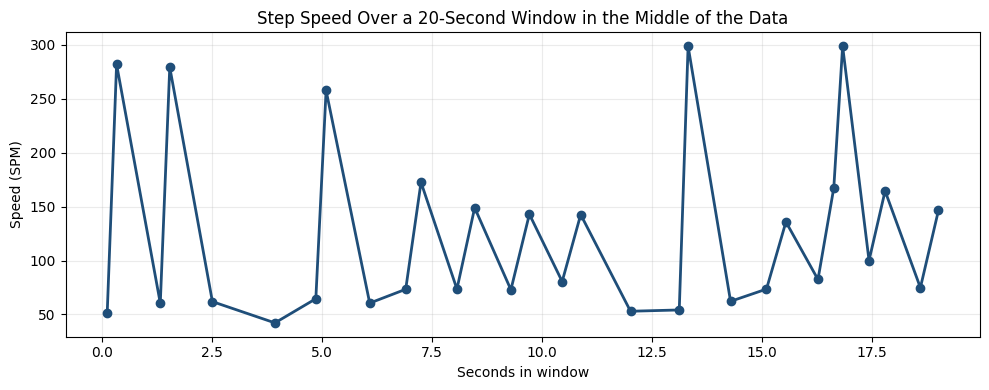

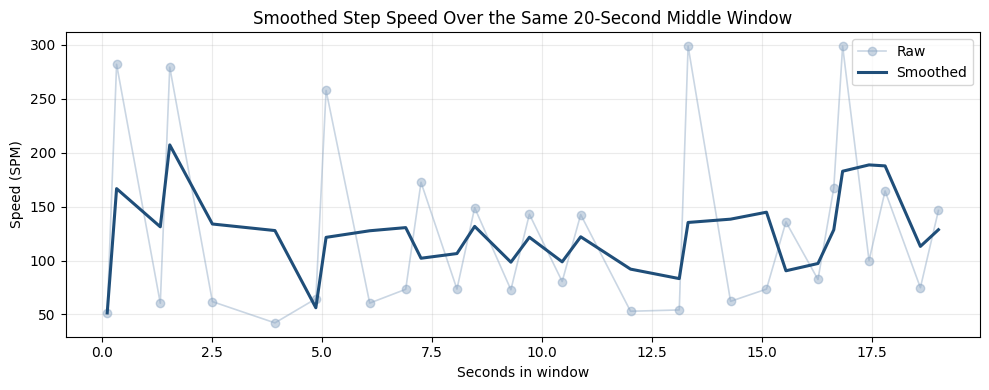

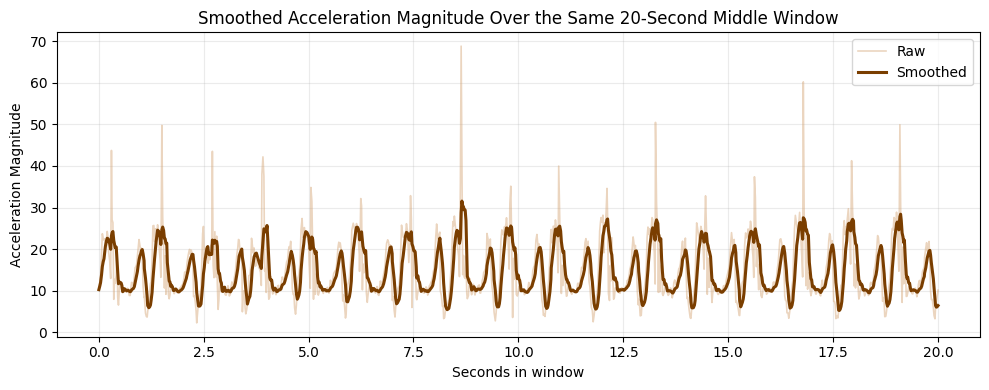

Saved graph to: ../results/sensor_step_speed_mid_20s.png
Saved graph to: ../results/sensor_step_speed_mid_20s_smoothed.png
Saved graph to: ../results/sensor_acceleration_mid_20s_smoothed.png
Plotted 30 step-speed points and 1030 acceleration samples from the middle window.


In [29]:
import matplotlib.pyplot as plt

valid_rows = [row for row in rows if row["speed_spm"] is not None]

if not valid_rows:
    print("Not enough detected steps to plot speed over time.")
else:
    first_timestamp_ms = valid_rows[0]["timestamp_ms"]
    last_timestamp_ms = valid_rows[-1]["timestamp_ms"]
    middle_timestamp_ms = (first_timestamp_ms + last_timestamp_ms) / 2

    window_half_ms = 10000
    window_start_ms = middle_timestamp_ms - window_half_ms
    window_end_ms = middle_timestamp_ms + window_half_ms

    window_rows = [
        row
        for row in valid_rows
        if window_start_ms <= row["timestamp_ms"] <= window_end_ms
    ]

    if len(window_rows) < 2:
        window_rows = valid_rows
        window_start_ms = window_rows[0]["timestamp_ms"]
        window_end_ms = window_rows[-1]["timestamp_ms"]

    x_seconds = [(row["timestamp_ms"] - window_start_ms) / 1000.0 for row in window_rows]
    y_speed_spm = [row["speed_spm"] for row in window_rows]
    y_speed_smoothed = moving_average(y_speed_spm, 3)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x_seconds, y_speed_spm, marker="o", linewidth=2, color="#1f4e79")
    ax.set_title("Step Speed Over a 20-Second Window in the Middle of the Data")
    ax.set_xlabel("Seconds in window")
    ax.set_ylabel("Speed (SPM)")
    ax.grid(alpha=0.25)
    fig.tight_layout()

    graph_path = OUTPUT_CSV.with_name("sensor_step_speed_mid_20s.png")
    fig.savefig(graph_path, dpi=160)
    plt.show()
    plt.close(fig)

    smooth_fig, smooth_ax = plt.subplots(figsize=(10, 4))
    smooth_ax.plot(x_seconds, y_speed_spm, marker="o", linewidth=1.2, color="#8aa5c2", alpha=0.45, label="Raw")
    smooth_ax.plot(x_seconds, y_speed_smoothed, linewidth=2.2, color="#1f4e79", label="Smoothed")
    smooth_ax.set_title("Smoothed Step Speed Over the Same 20-Second Middle Window")
    smooth_ax.set_xlabel("Seconds in window")
    smooth_ax.set_ylabel("Speed (SPM)")
    smooth_ax.grid(alpha=0.25)
    smooth_ax.legend()
    smooth_fig.tight_layout()

    smooth_graph_path = OUTPUT_CSV.with_name("sensor_step_speed_mid_20s_smoothed.png")
    smooth_fig.savefig(smooth_graph_path, dpi=160)
    plt.show()
    plt.close(smooth_fig)

    window_samples = [
        (timestamp_ms, magnitude)
        for timestamp_ms, magnitude in zip(timestamps_ms, magnitudes)
        if window_start_ms <= timestamp_ms <= window_end_ms
    ]

    if len(window_samples) < 2:
        print("Not enough accelerometer samples in the middle window to plot acceleration.")
    else:
        accel_x_seconds = [(timestamp_ms - window_start_ms) / 1000.0 for timestamp_ms, _ in window_samples]
        accel_magnitude = [magnitude for _, magnitude in window_samples]
        accel_smoothed = moving_average(accel_magnitude, 7)

        accel_fig, accel_ax = plt.subplots(figsize=(10, 4))
        accel_ax.plot(accel_x_seconds, accel_magnitude, linewidth=1.2, color="#d4a373", alpha=0.45, label="Raw")
        accel_ax.plot(accel_x_seconds, accel_smoothed, linewidth=2.2, color="#7a3e00", label="Smoothed")
        accel_ax.set_title("Smoothed Acceleration Magnitude Over the Same 20-Second Middle Window")
        accel_ax.set_xlabel("Seconds in window")
        accel_ax.set_ylabel("Acceleration Magnitude")
        accel_ax.grid(alpha=0.25)
        accel_ax.legend()
        accel_fig.tight_layout()

        accel_graph_path = OUTPUT_CSV.with_name("sensor_acceleration_mid_20s_smoothed.png")
        accel_fig.savefig(accel_graph_path, dpi=160)
        plt.show()
        plt.close(accel_fig)

        print(f"Saved graph to: {graph_path}")
        print(f"Saved graph to: {smooth_graph_path}")
        print(f"Saved graph to: {accel_graph_path}")
        print(f"Plotted {len(window_rows)} step-speed points and {len(window_samples)} acceleration samples from the middle window.")

## Output

The notebook writes a combined CSV with one row per detected step. The first detected step has no speed value because there is no previous step to compare against.